In [26]:
%matplotlib inline
import os
import re
import numpy as np
import matplotlib.pyplot as plt

import regex

param_grid = {
    "name": ["SIRA", "PIGEON", "TABAF"],
    "nGrounds": [30],
    "nFerrys": [1, 3, 5, 10],
    "groundBufferSize": [1000],
    "ferryBufferSize": [500],
    "bundleGenRate": [10.0, 30.0],
    "bundleTTL": [300,600, 1200],
    "ferryComm": [False, True],
}

# ==============================
# CONFIG
# ==============================
REPORT_DIR = "../report/20260301_1am"  # thư mục chứa report


def get_value(value_name: str, content: str) -> str:
    lines = content.split("\n")
    for line in lines:
        if line.startswith(value_name):
            line = line.split(":")[1]
            line = line.strip().split(" ")[0]
            return line
    return ""


def load_report_file(filepath: str) -> dict:
    with open(filepath, "r") as f:
        content = f.read()

    result = {}

    # Config
    result["name"] = get_value("Algorithm", content)
    result["nGrounds"] = int(get_value("Number of Grounds", content))
    result["nFerrys"] = int(get_value("Number of Ferries", content))
    result["groundBufferSize"] = int(get_value("Ground Buffer Size", content))
    result["ferryBufferSize"] = int(get_value("Ferry Buffer Size", content))
    result["bundleGenRate"] = float(get_value("Bundle Generation Rate", content))
    result["bundleTTL"] = float(get_value("Bundle TTL", content))
    result["ferryComm"] = bool(int(get_value("Enable Ferry Communication", content)))
    # Metrics
    result["Delivery Ratio"] = float(get_value("Delivery Ratio", content))
    result["Average Delay"] = float(get_value("Average Delay", content))
    result["Dead Connection"] = int(get_value("Dead Connection", content))
    result["Low Connection (1%)"] = int(get_value(f"Low Connection (1%)", content))
    result["Low Connection (2%)"] = int(get_value(f"Low Connection (2%)", content))
    result["Low Connection (5%)"] = int(get_value(f"Low Connection (5%)", content))
    result["Low Connection (10%)"] = int(get_value(f"Low Connection (10%)", content))
    result["Low Connection (20%)"] = int(get_value(f"Low Connection (20%)", content))

    # bạn có thể thêm các metric khác nếu cần
    return result


def check_param_match(report_data: dict, param_grid: dict) -> bool:
    for key, values in param_grid.items():
        if report_data.get(key) not in values:
            return False
    return True


def load_all_reports(report_dir: str) -> list:
    all_reports = []
    for filename in os.listdir(report_dir):
        if filename.endswith(".log"):
            filepath = os.path.join(report_dir, filename)
            report_data = load_report_file(filepath)
            if check_param_match(report_data, param_grid):
                all_reports.append(report_data)
    return all_reports

{'name': 'PIGEON', 'nGrounds': 30, 'nFerrys': 10, 'groundBufferSize': 1000, 'ferryBufferSize': 500, 'bundleGenRate': 10.0, 'bundleTTL': 1200.0, 'ferryComm': False, 'Delivery Ratio': 0.399938, 'Average Delay': 302.95, 'Dead Connection': 1, 'Low Connection (1%)': 1, 'Low Connection (2%)': 1, 'Low Connection (5%)': 2, 'Low Connection (10%)': 4, 'Low Connection (20%)': 30}


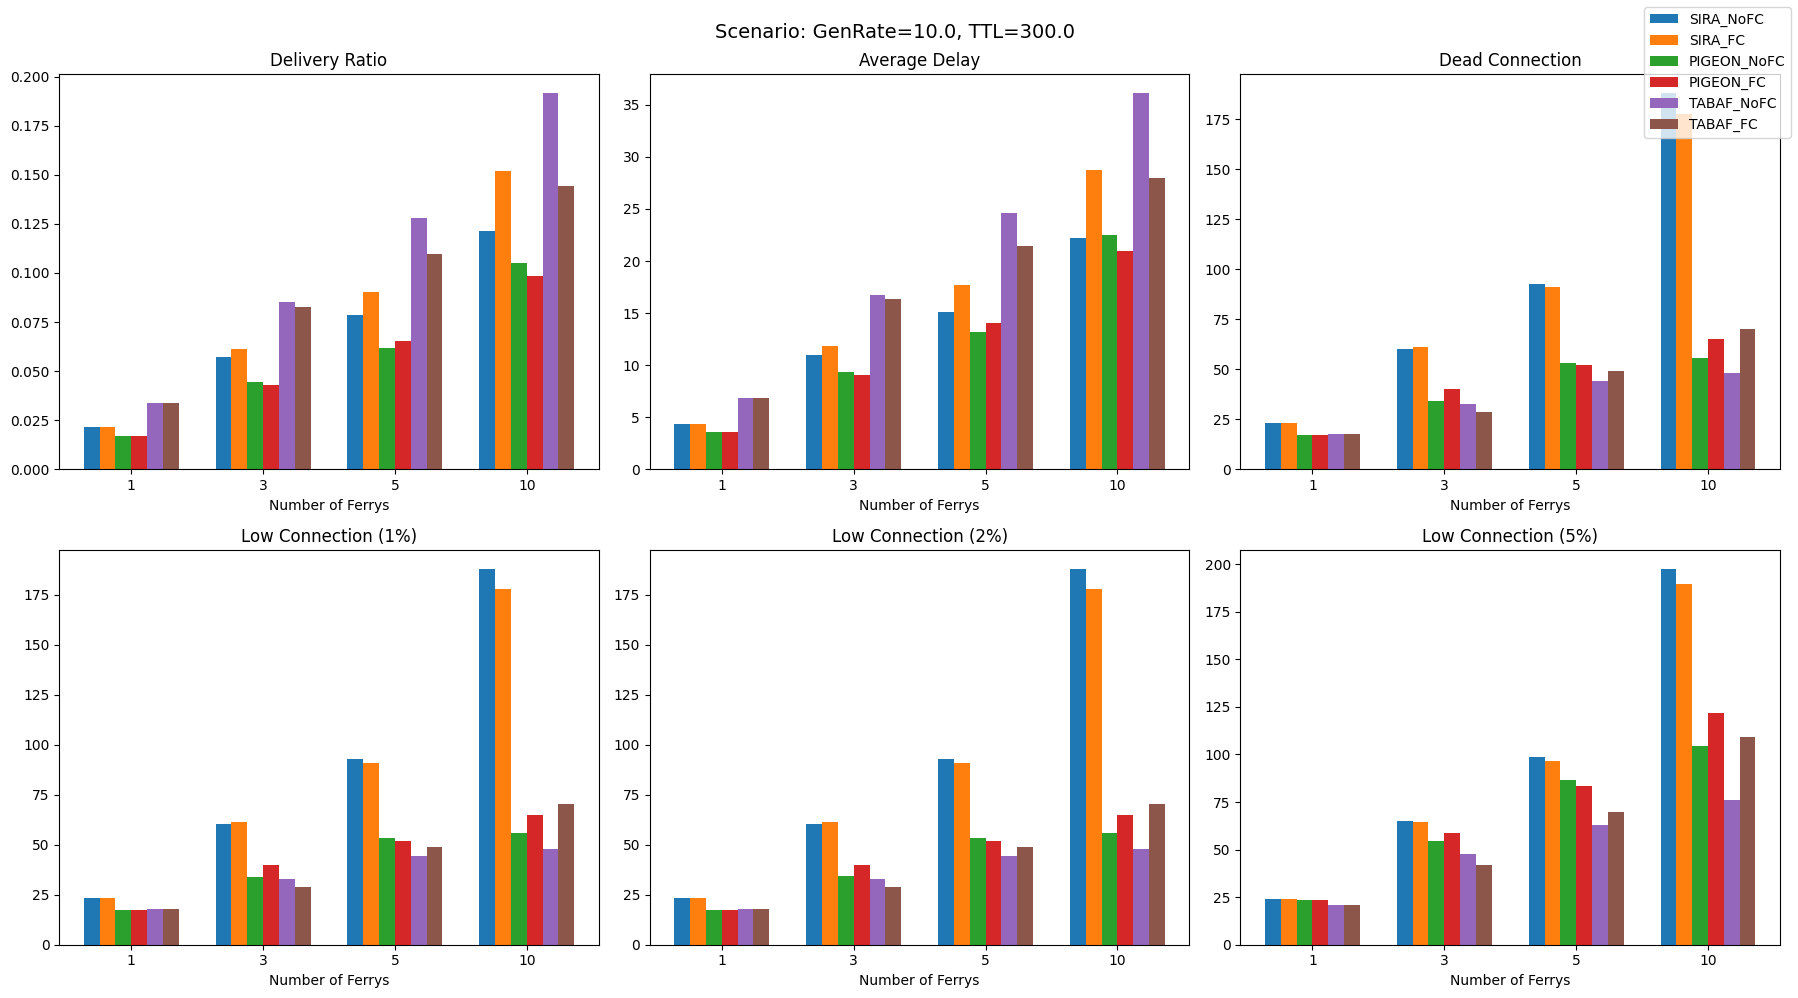

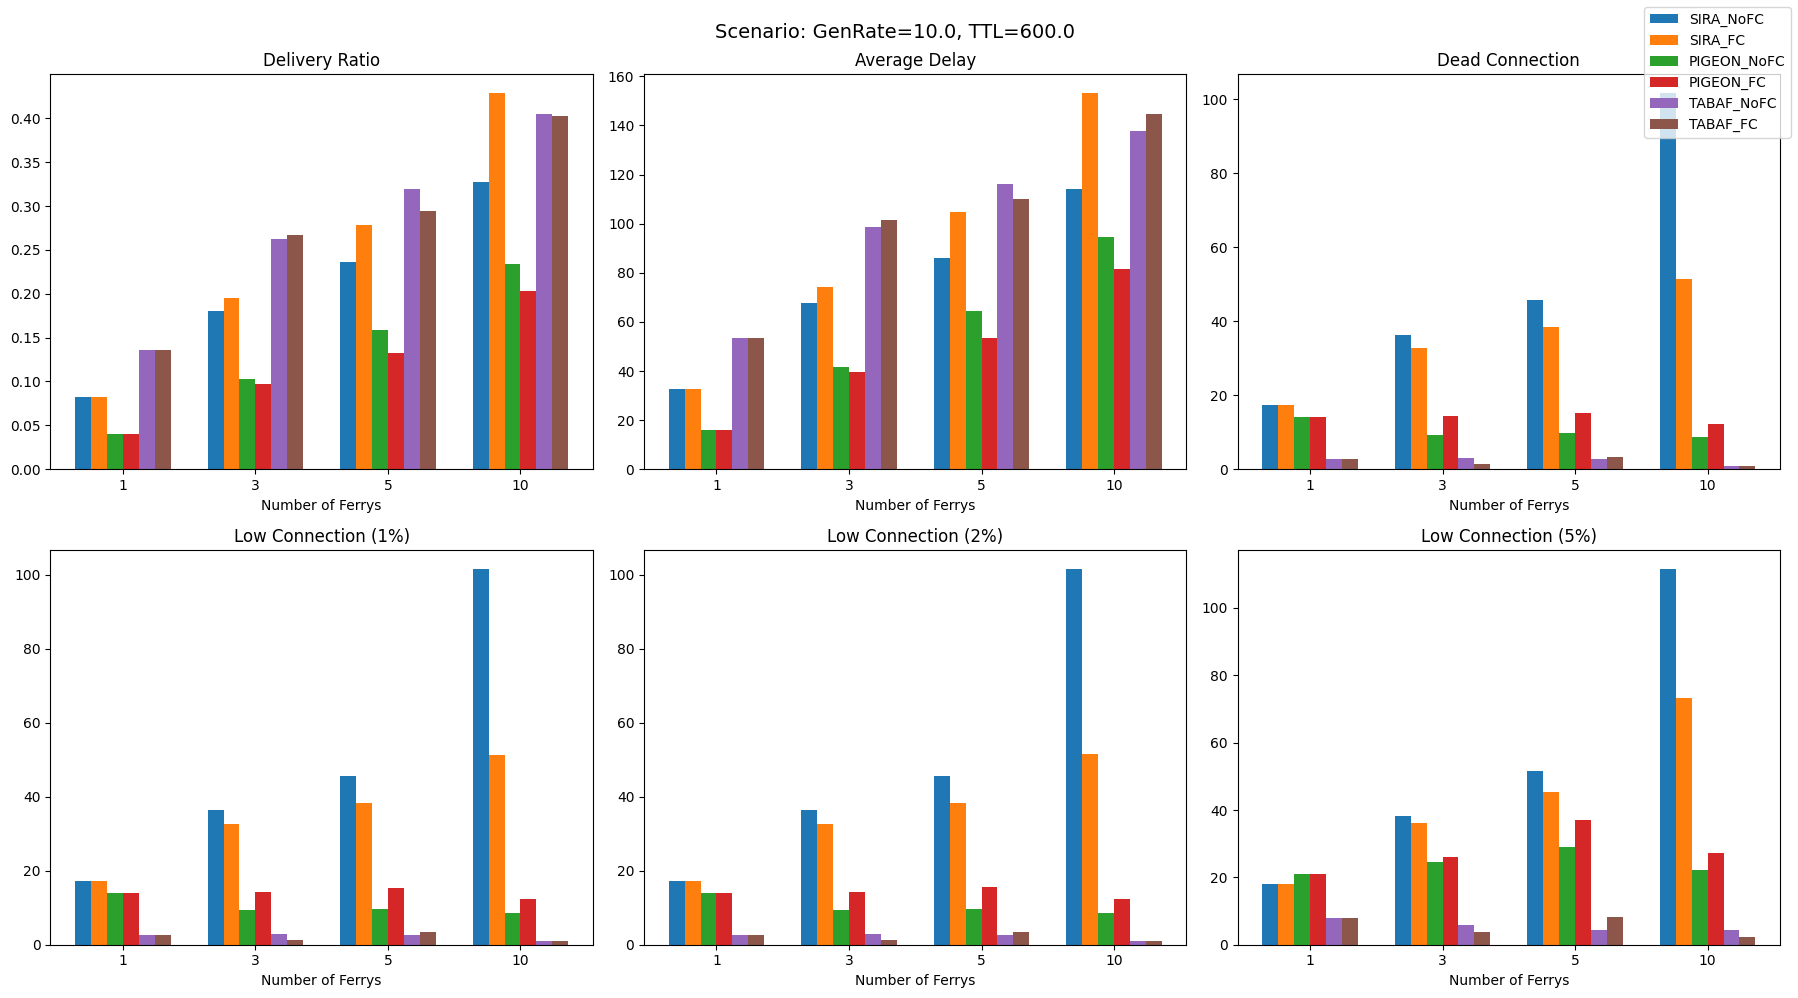

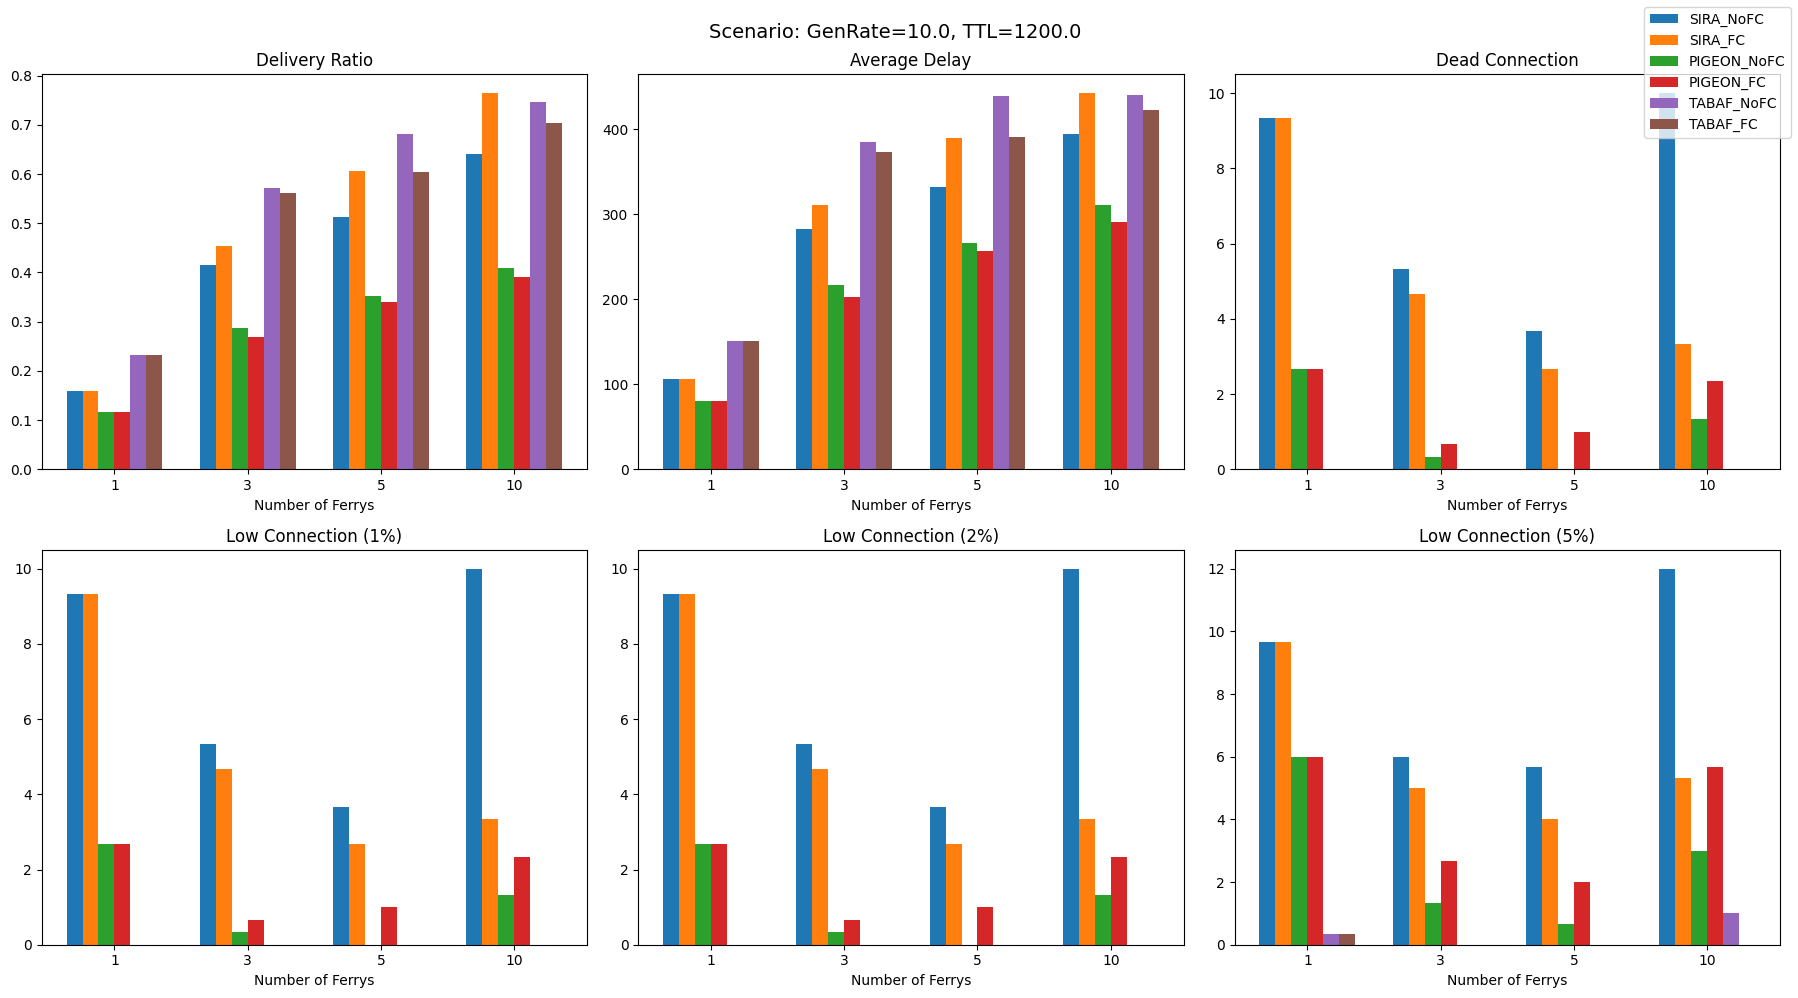

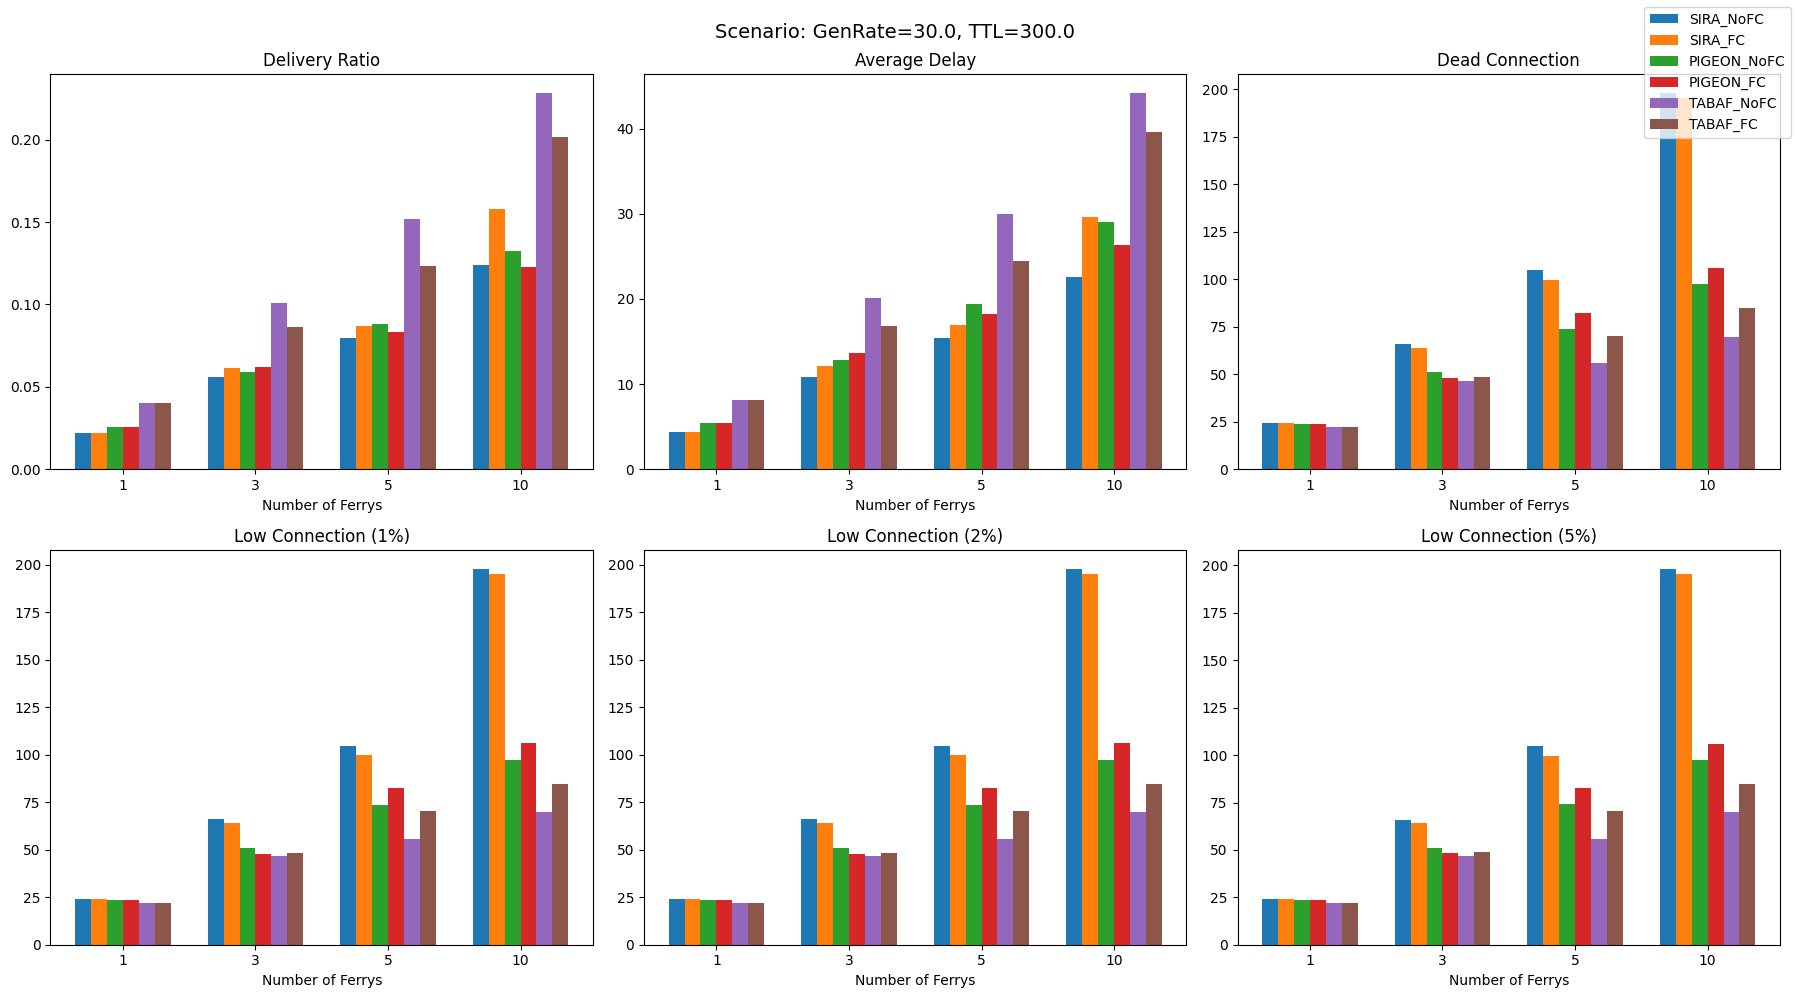

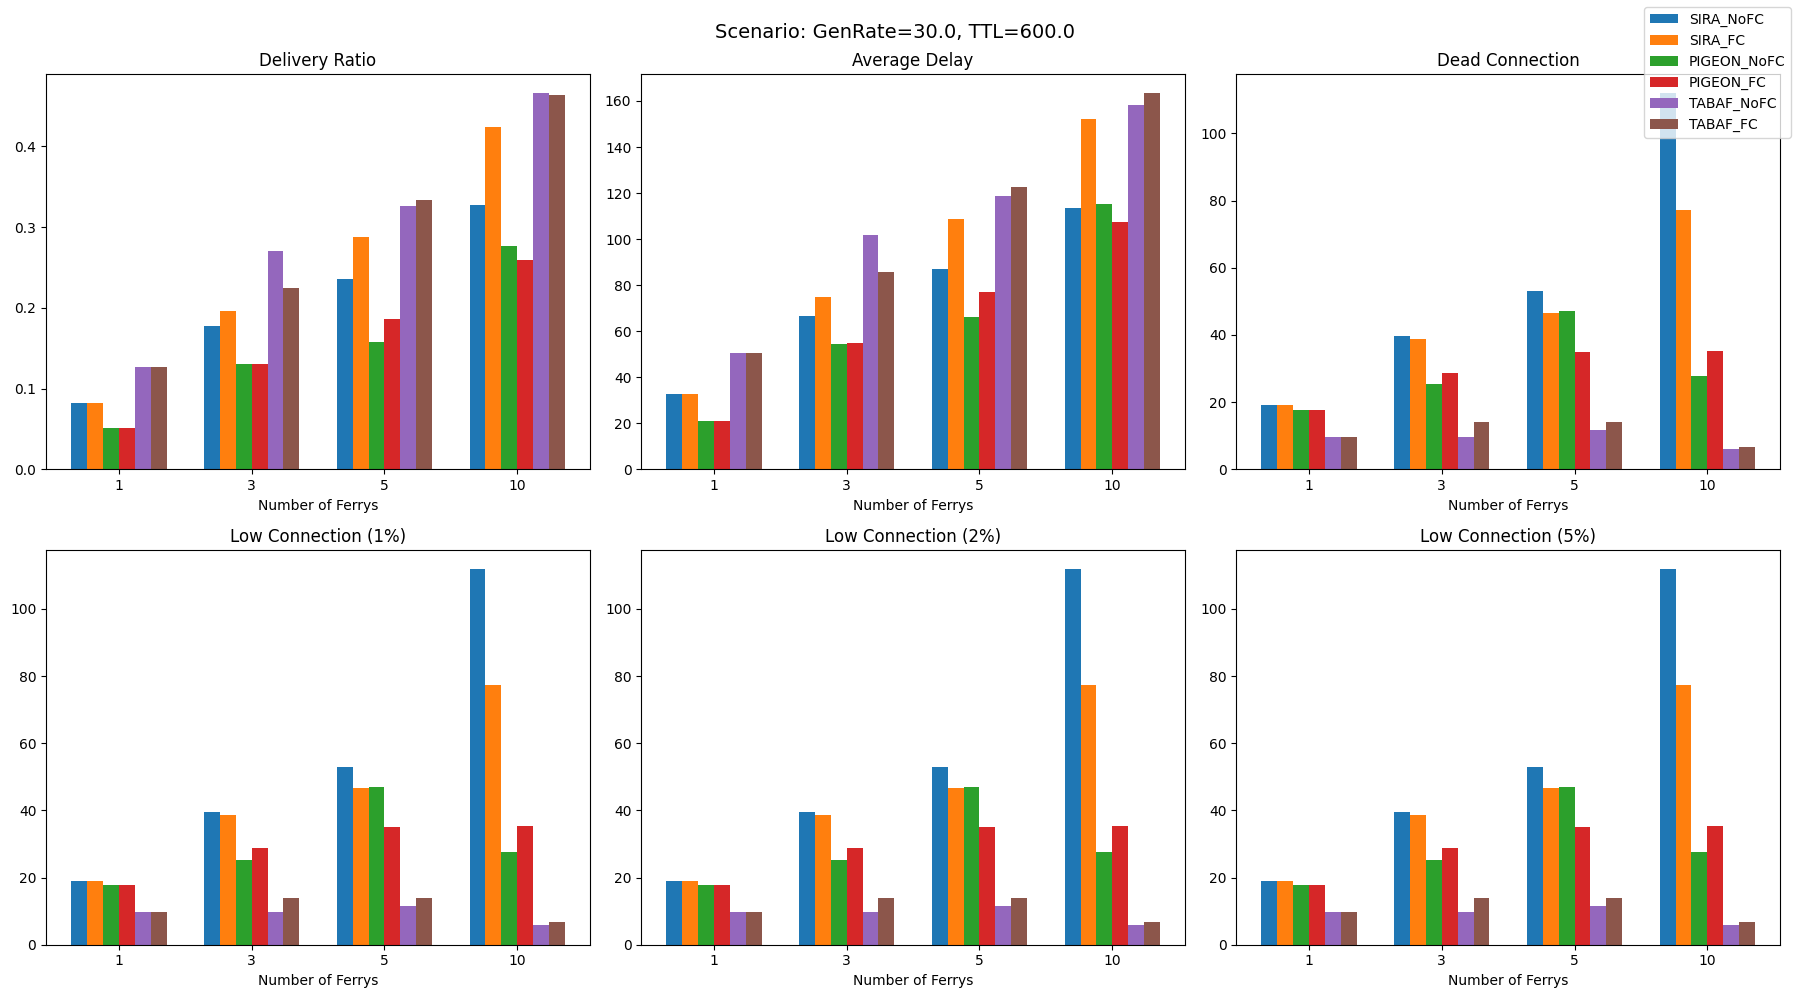

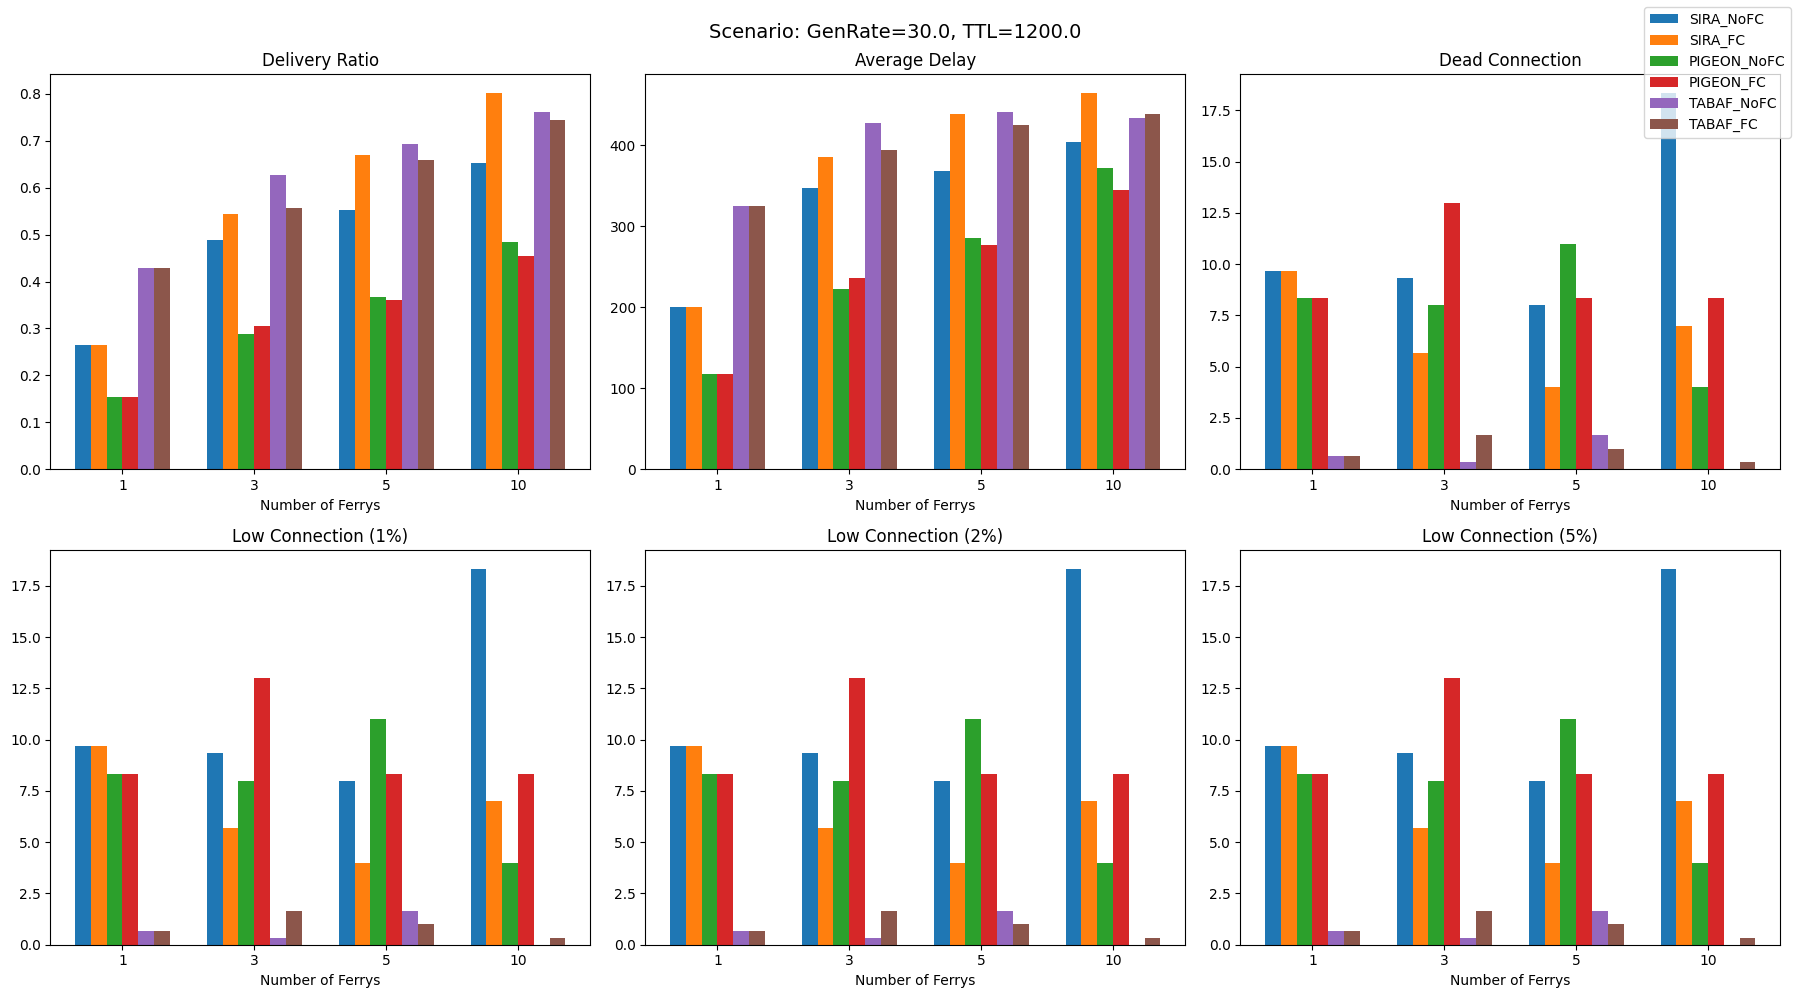

In [27]:
# ==============================
# AGGREGATE DATA
# ==============================


def aggregate_reports(all_reports):
    """
    Trả về:
    data[scenario_key][metric][nFerrys][setup] = mean_value
    """
    data = {}

    for report in all_reports:
        scenario_key = (report["bundleGenRate"], report["bundleTTL"])

        setup = f"{report['name']}_{'FC' if report['ferryComm'] else 'NoFC'}"
        nFerrys = report["nFerrys"]

        if scenario_key not in data:
            data[scenario_key] = {}

        metrics = [
            "Delivery Ratio",
            "Average Delay",
            "Dead Connection",
            "Low Connection (1%)",
            "Low Connection (2%)",
            "Low Connection (5%)",
            "Low Connection (10%)",
            "Low Connection (20%)",
        ]

        for metric in metrics:
            data.setdefault(scenario_key, {}).setdefault(metric, {}).setdefault(
                nFerrys, {}
            ).setdefault(setup, []).append(report[metric])

    # tính mean
    for scenario in data:
        for metric in data[scenario]:
            for nF in data[scenario][metric]:
                for setup in data[scenario][metric][nF]:
                    values = data[scenario][metric][nF][setup]
                    data[scenario][metric][nF][setup] = np.mean(values)

    return data


# ==============================
# PLOTTING
# ==============================


def plot_all_scenarios(data):

    setups = []
    for name in param_grid["name"]:
        setups.append(f"{name}_NoFC")
        setups.append(f"{name}_FC")

    nFerrys_values = param_grid["nFerrys"]

    metrics_to_plot = [
        "Delivery Ratio",
        "Average Delay",
        "Dead Connection",
        "Low Connection (1%)",
        "Low Connection (2%)",
        "Low Connection (5%)",
    ]

    for scenario_key in sorted(data.keys()):
        bundleGenRate, bundleTTL = scenario_key

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        width = 0.12
        x = np.arange(len(nFerrys_values))

        for ax, metric in zip(axes, metrics_to_plot):

            for i, setup in enumerate(setups):
                values = []

                for nF in nFerrys_values:
                    val = data[scenario_key].get(metric, {}).get(nF, {}).get(setup, 0)
                    values.append(val)

                ax.bar(x + i * width, values, width, label=setup)

            ax.set_title(metric)
            ax.set_xticks(x + width * 2.5)
            ax.set_xticklabels(nFerrys_values)
            ax.set_xlabel("Number of Ferrys")

        fig.suptitle(f"Scenario: GenRate={bundleGenRate}, TTL={bundleTTL}", fontsize=14)

        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right")

        plt.tight_layout()
        plt.show()


# ==============================
# RUN
# ==============================

all_reports = load_all_reports(REPORT_DIR)
data = aggregate_reports(all_reports)
print(all_reports[0])
plot_all_scenarios(data)